# Image Analysis Workshop Demo

In [1]:
# Load the necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import PIL.Image as Image
from PIL import ImageFilter
import cv2
import plotly.express as px
import plotly.graph_objects as go
import textwrap

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

import torch
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision.transforms import functional as TF

This notebook uses a subset of the **Documerica** dataset, a 1970s EPA photo archive documenting environmental conditions across the United States.

The subset includes:
1. **Images**: JPG files in `data/documerica_subset`.
2. **Metadata**: `data/subset_documerica_metadata_labeled.csv` with fields such as:
   - `nid`: unique image identifier
   - `title`: short description of scene context
   - `Photographer`: photographer name
   - `date`: capture date
   - `place_name`: location name
   - `coordinates`: latitude/longitude
   - `category`: a descriptive label generated by a Vision-Language Model (e.g., **Pollution and Environmental Damage**, **Urban Landscape**, **Transportation and Infrastructure**, etc.)

We will connect pixel-level patterns to metadata-level context through progressively more automated analysis.

In [2]:
IMAGE_DIR = "data/documerica_subset"

# Load relabeled metadata (labels generated by a Vision-Language Model)
meta_df = pd.read_csv("data/subset_documerica_metadata_labeled.csv")

# Display the information about the metadata
print(meta_df.info())
print("\nCategory counts:")
print(meta_df["category"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nid                197 non-null    int64  
 1   date               196 non-null    str    
 2   title              197 non-null    str    
 3   agency_id          196 non-null    str    
 4   nail_num           197 non-null    str    
 5   img_url            197 non-null    str    
 6   img_path           197 non-null    str    
 7   photographer       190 non-null    str    
 8   photographer_desc  160 non-null    str    
 9   birth_year         128 non-null    float64
 10  death_year         39 non-null     float64
 11  id                 184 non-null    float64
 12  place_name         184 non-null    str    
 13  coordinates        184 non-null    str    
 14  category           197 non-null    str    
dtypes: float64(3), int64(1), str(11)
memory usage: 150.2 KB
None

Category counts:
catego

In [3]:
# Show unique labels of the dataset
meta_df['category'].unique()

<ArrowStringArray>
['Pollution and Environmental Damage',                'Nature and Wildlife',
  'Transportation and Infrastructure',                    'Urban Landscape',
                    'Rural Landscape',                    'Industrial Site',
            'Agriculture and Farming',               'People and Community']
Length: 8, dtype: str

## 1. Manual Image Transformations

This section builds intuition for how simple operations change the visual signal before automation.

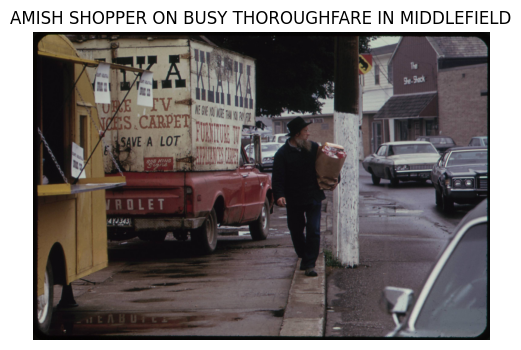

In [4]:
# Load an image and display it
sample_nid = 550128

sample_image_path = os.path.join(IMAGE_DIR, f"{sample_nid}.jpg")
sample_image = Image.open(sample_image_path)

# Display the image and its title
plt.figure(figsize=(8, 4))
plt.imshow(sample_image)

# Filter for the row with the specific nid
record = meta_df[meta_df['nid'] == sample_nid]

plt.title(textwrap.fill(record['title'].values[0], width=50))

plt.axis('off')
plt.show()

### 1.1 Color Channels and Pixel Distributions

Channel balance and intensity histograms help explain color composition in the scene.

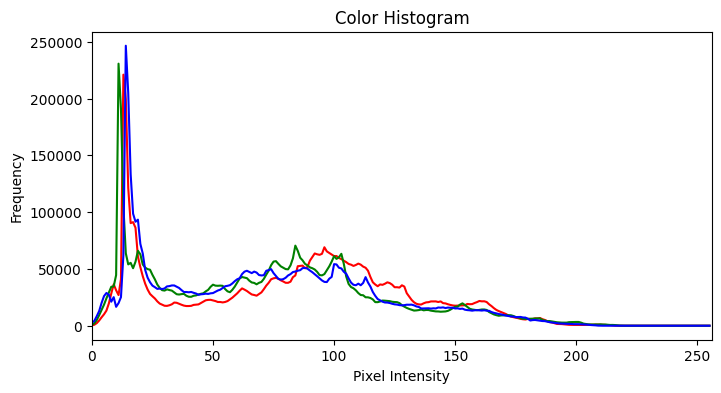

In [5]:
# Color histogram of the image
sample_img_rgb = np.array(sample_image)

color = ('r', 'g', 'b')
plt.figure(figsize=(8, 4))
for i, col in enumerate(color):
    histogram = cv2.calcHist([sample_img_rgb], [i], None, [256], [0, 256])
    plt.plot(histogram, color=col)
    plt.xlim([0, 256])
plt.title("Color Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

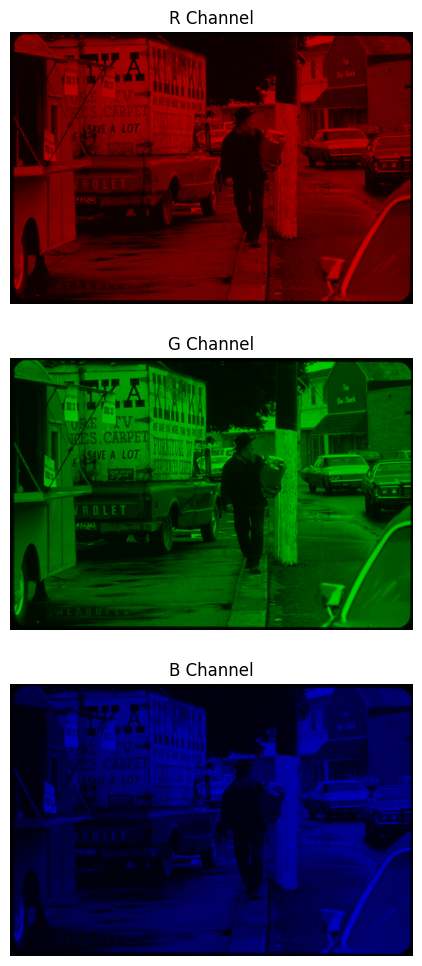

In [6]:
# Different color channels of the image
channels = cv2.split(sample_img_rgb) # Splits into R, G, B components
zeros = np.zeros_like(channels[0])

plt.figure(figsize=(8, 12))
for i, col in enumerate(color):
    plt.subplot(3, 1, i + 1)
    
    channel_image_components = [zeros, zeros, zeros]
    channel_image_components[i] = channels[i]
    
    # Merge these components back into an RGB image
    colored_channel_img = cv2.merge(channel_image_components)
    
    plt.imshow(colored_channel_img)
    plt.title(f"{col.upper()} Channel")
    plt.axis('off')
plt.show()

A GIF showing how separate color channels combine into a full-color image:
<img src="media/channel_merge_demo.gif" width="500">

RGB channels carry complementary information, and recombining them restores scene detail.

### 1.2 Convolution, Filtering, and Edges

Filters emphasize different structures (texture, boundaries, or contrast) that later support feature extraction.

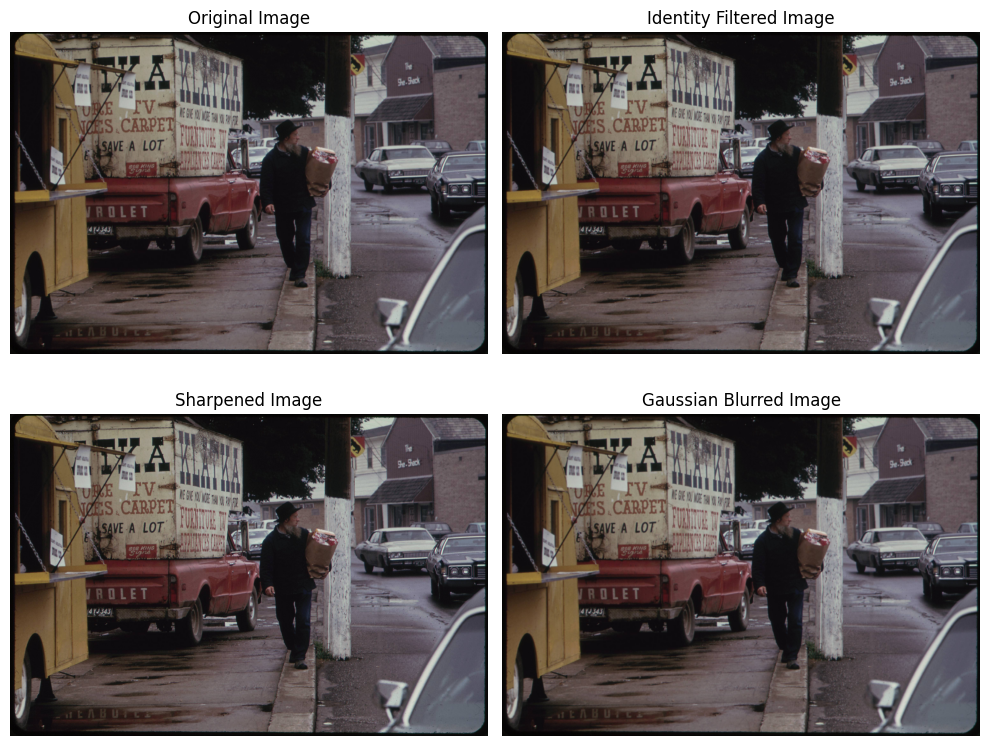

In [7]:
# Apply the identity filter to the image
identity_kernel = np.array([[0, 0, 0], 
                            [0, 1, 0],
                            [0, 0, 0]])
identity_image = cv2.filter2D(sample_img_rgb, -1, identity_kernel)

# Apply sharpening filter to the image
sharpening_kernel = np.array([[0, -1, 0], 
                             [-1, 5, -1], 
                             [0, -1, 0]])
sharpened_image = cv2.filter2D(sample_img_rgb, -1, sharpening_kernel)

# Apply the Gaussian blur to the image
blurred_image = cv2.GaussianBlur(sample_img_rgb, (5, 5), 0)


# Display the original and sharpened images
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(sample_image)
axes[0, 0].set_title("Original Image") 
axes[0, 1].imshow(identity_image)
axes[0, 1].set_title("Identity Filtered Image")
axes[1, 0].imshow(sharpened_image)
axes[1, 0].set_title("Sharpened Image")
axes[1, 1].imshow(blurred_image)
axes[1, 1].set_title("Gaussian Blurred Image")
for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()


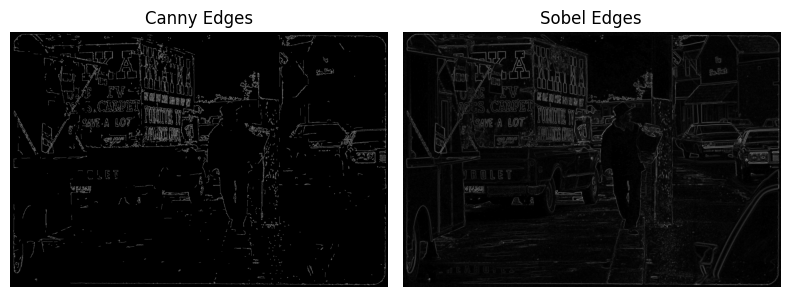

In [8]:
# Apply the Canny edge detection algorithm to the sharpened image
gray = cv2.cvtColor(sample_img_rgb, cv2.COLOR_RGB2GRAY)

# Apply sharpening to the grayscale image
gray_sharpened = cv2.filter2D(gray, -1, sharpening_kernel)

edges = cv2.Canny(gray_sharpened, 100, 200)

# Apply the sobel edge detection algorithm to the sharpened image
sobelx = cv2.Sobel(gray_sharpened, cv2.CV_64F, 1, 0, ksize=5)  # Sobel X
sobely = cv2.Sobel(gray_sharpened, cv2.CV_64F, 0, 1, ksize=5)  # Sobel Y
sobel_edges = cv2.magnitude(sobelx, sobely)  # Combine X and Y edges

# Display the edges 
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel Edges")
plt.axis('off')
plt.tight_layout()
plt.show()

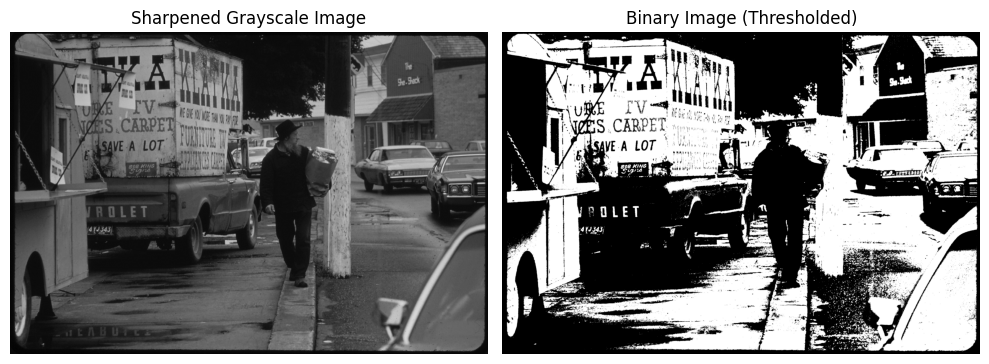

In [9]:
# Absolute thresholding to create a binary image
absolute_threshold = 80
_, binary_image = cv2.threshold(gray_sharpened, absolute_threshold, 255, cv2.THRESH_BINARY)

# Display the binary image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gray_sharpened, cmap='gray')
ax[0].set_title("Sharpened Grayscale Image")
ax[0].axis('off')
ax[1].imshow(binary_image, cmap='gray')
ax[1].set_title("Binary Image (Thresholded)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

### 1.3 Geometric Augmentation and Region-Based Focus

Geometric transforms and masking reveal which visual changes preserve or distort useful structure.

Common augmentations include resizing, rotation, flipping, and filtering to simulate variation while preserving core scene content.

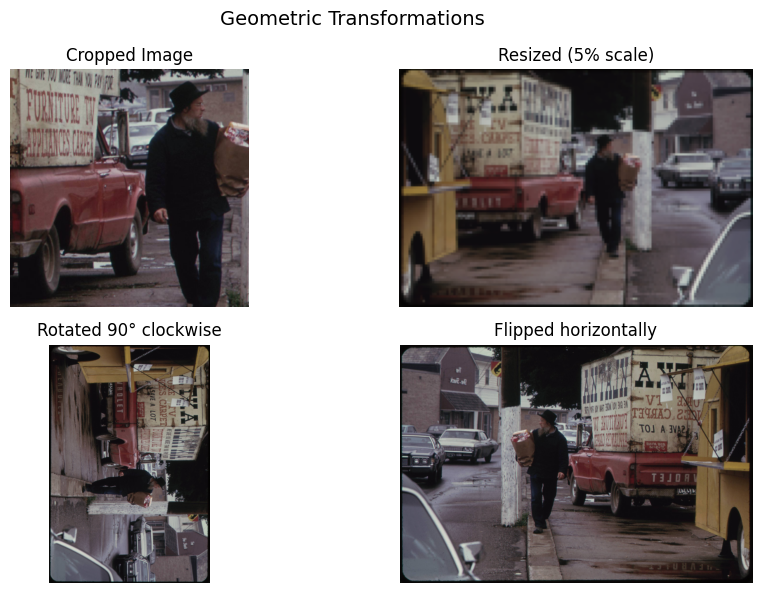

In [10]:
# A few geometric transformations to see how image structure changes
cropped_img = sample_img_rgb[500:1500, 1000:2000]  # Crop the image to a specific region
resized_img = cv2.resize(sample_img_rgb, None, fx=0.05, fy=0.05, interpolation=cv2.INTER_AREA)
rotated_img = cv2.rotate(sample_img_rgb, cv2.ROTATE_90_CLOCKWISE)
flipped_img = cv2.flip(sample_img_rgb, 1)  # 1 = horizontal flip

# Show transformed images side by side so the differences are easy to spot
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax[0, 0].imshow(cropped_img)
ax[0, 0].set_title("Cropped Image")
ax[0, 0].axis("off")


ax[0, 1].imshow(resized_img)
ax[0, 1].set_title("Resized (5% scale)")
ax[0, 1].axis("off")



ax[1, 0].imshow(rotated_img)
ax[1, 0].set_title("Rotated 90° clockwise")
ax[1, 0].axis("off")



ax[1, 1].imshow(flipped_img)
ax[1, 1].set_title("Flipped horizontally")
ax[1, 1].axis("off")



plt.suptitle("Geometric Transformations", fontsize=14)
plt.tight_layout()
plt.show()

Beyond cropping, masking is a practical way to isolate regions of interest and suppress distracting background content.

In workflows like object localization, segmentation, and document cleanup, masks help focus computation on the most informative pixels.

Selective visibility changes what the model can learn, so region choice directly affects downstream results.

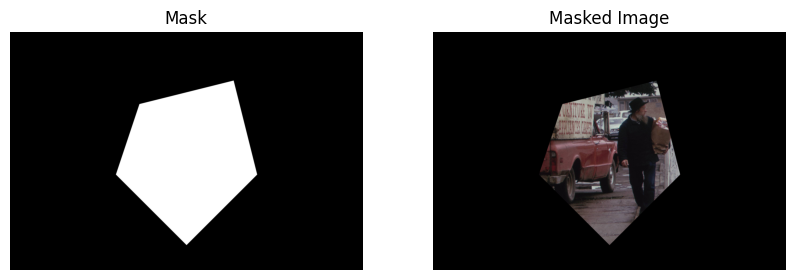

In [11]:
# Apply an irregular polygonal mask to the image
mask = np.zeros(sample_img_rgb.shape[:2], dtype="uint8")
(cX, cY) = (sample_img_rgb.shape[1] // 2, sample_img_rgb.shape[0] // 2)

# Create an irregular shape using points
pts = np.array([[cX - 400, cY - 400], [cX + 400, cY - 600], 
                [cX + 600, cY + 200], [cX, cY + 800], 
                [cX - 600, cY + 200]], np.int32)
pts = pts.reshape((-1, 1, 2))
cv2.fillPoly(mask, [pts], 255)

# Apply the mask
masked = cv2.bitwise_and(sample_img_rgb, sample_img_rgb, mask=mask)

# Display the mask and the masked image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masked)
plt.title("Masked Image")
plt.axis('off')
plt.show()

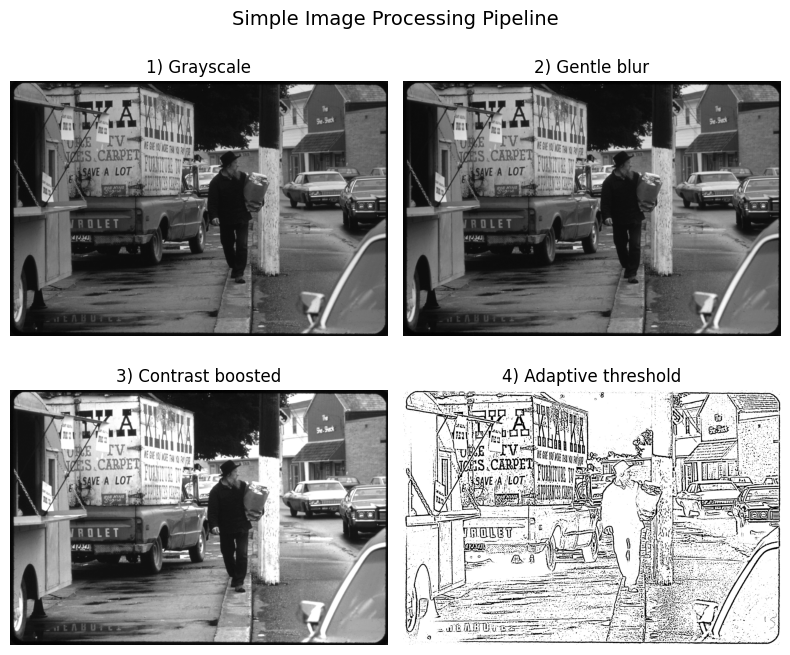

In [12]:
# Better thresholding for edge detection: blur -> contrast boost -> threshold
def process_image_pipeline(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    high_contrast = cv2.convertScaleAbs(blurred, alpha=1.6, beta=10)
    binary = cv2.adaptiveThreshold(
        high_contrast, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 21, 4
    )
    return gray, blurred, high_contrast, binary

# Apply the pipeline to the sample image
gray, blurred, high_contrast, binary = process_image_pipeline(sample_img_rgb)

fig, ax = plt.subplots(2, 2, figsize=(8, 7))
ax[0, 0].imshow(gray, cmap="gray")
ax[0, 0].set_title("1) Grayscale")
ax[0, 0].axis("off")

ax[0, 1].imshow(blurred, cmap="gray")
ax[0, 1].set_title("2) Gentle blur")
ax[0, 1].axis("off")

ax[1, 0].imshow(high_contrast, cmap="gray")
ax[1, 0].set_title("3) Contrast boosted")
ax[1, 0].axis("off")

ax[1, 1].imshow(binary, cmap="gray")
ax[1, 1].set_title("4) Adaptive threshold")
ax[1, 1].axis("off")

plt.suptitle("Simple Image Processing Pipeline", fontsize=14)
plt.tight_layout()
plt.show()

What if we are interested in reading a specific text in the image?

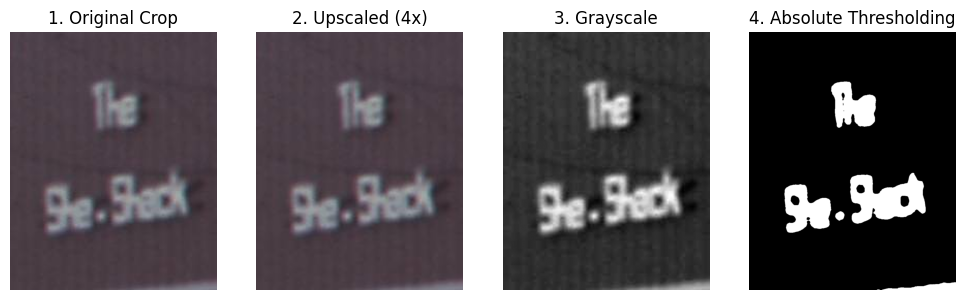

In [13]:
# Coordinates found by inspection: y=150:450, x=2400:2600
roi = sample_img_rgb[150:400, 2400:2600]

# Upscale the image to make the text larger 
scale_factor = 4
width = int(roi.shape[1] * scale_factor)
height = int(roi.shape[0] * scale_factor)
upscaled = cv2.resize(roi, (width, height), interpolation=cv2.INTER_CUBIC)

# Enhance readability using image processing
# Convert to grayscale
gray_roi = cv2.cvtColor(upscaled, cv2.COLOR_RGB2GRAY)

# Apply a stronger blur to remove more noise before thresholding
blurred_roi = cv2.GaussianBlur(gray_roi, (5, 5), 0)

# Apply an absolute threshold to highlight the text
threshold_value = 101
binary_text = cv2.threshold(blurred_roi, threshold_value, 255, cv2.THRESH_BINARY)[1]

# Display the steps
fig, ax = plt.subplots(1, 4, figsize=(10, 3))

ax[0].imshow(roi)
ax[0].set_title("1. Original Crop")
ax[0].axis("off")

ax[1].imshow(upscaled)
ax[1].set_title(f"2. Upscaled ({scale_factor}x)")
ax[1].axis("off")

ax[2].imshow(gray_roi, cmap='gray')
ax[2].set_title("3. Grayscale")
ax[2].axis("off")

ax[3].imshow(binary_text, cmap='gray')
ax[3].set_title("4. Absolute Thresholding")
ax[3].axis("off")

plt.tight_layout()
plt.show()

## 2. Automating Analysis with Similarity and Clustering

Now we move from manual inspection to feature-based comparison: each image becomes a numeric vector, and cosine similarity measures how close two images are in that feature space.

This step scales qualitative visual reasoning into a reproducible quantitative workflow.

We begin by building a small working corpus.

In [14]:
# BoVW setup: collect a small batch of images and extract local features.
# Let's grab a random sample of images to analyze, rather than just the first few.
max_images = 50

# Filter for valid records and pick a random batch
demo_df = meta_df.sample(n=min(max_images, len(meta_df)), random_state=123).reset_index(drop=True)
# Build the full file paths to load the images more easily
demo_df["img_path"] = demo_df["nid"].astype(int).astype(str) + ".jpg"
demo_df["full_path"] = demo_df["img_path"].apply(lambda p: os.path.join(IMAGE_DIR, p))

# Display the distribution of categories in the sampled batch
category_counts = demo_df['category'].value_counts()
print("Category distribution in the sampled batch:")
print(category_counts)

Category distribution in the sampled batch:
category
Pollution and Environmental Damage    15
Urban Landscape                        9
Transportation and Infrastructure      9
Industrial Site                        7
Rural Landscape                        7
Nature and Wildlife                    1
Agriculture and Farming                1
People and Community                   1
Name: count, dtype: int64


#### 2.1 Extracting Visual Word Features

Preprocessing and standardization are important here because more consistent inputs usually produce more stable features and cleaner similarity structure.

In [15]:
# Define a preprocessing function to prepare images for feature extraction
def preprocess_for_bovw(img_bgr, use_standardization=True):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # standardization using mean and std
    if use_standardization:
        gray_f = gray.astype(np.float32)
        gray_f = (gray_f - gray_f.mean()) / (gray_f.std() + 1e-6)
        gray = cv2.normalize(gray_f, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    gray = cv2.convertScaleAbs(gray, alpha=1.6, beta=10)
    return gray

In [16]:
# Initialize the SIFT feature detector
detector = cv2.SIFT_create()
mode_name = "SIFT"

descriptors_per_image = []
valid_indices = []
skipped_images = 0

# Loop through our random batch and extract local features from preprocessed images.
for i, row in demo_df.iterrows():
    path = row["full_path"]

    # OpenCV loads color images in BGR format.
    img_bgr = cv2.imread(path)

    prepped_gray = preprocess_for_bovw(img_bgr)
    _, descriptors = detector.detectAndCompute(prepped_gray, None)

    descriptors_per_image.append(descriptors)
    valid_indices.append(i)

# Keep only rows that produced usable descriptors.
demo_df = demo_df.iloc[valid_indices].reset_index(drop=True)

print(f"Processed {len(demo_df)} images with {mode_name} visual features ")

Processed 50 images with SIFT visual features 


In [17]:
# Build the visual vocabulary (the 'words') and convert each image to a histogram.
# Intuitively, each bin stores how often a visual pattern appears.
all_descriptors = np.vstack(descriptors_per_image).astype(np.float32)
vocab_size = min(60, max(20, len(all_descriptors) // 80))
vocab_model = MiniBatchKMeans(n_clusters=vocab_size, random_state=42, batch_size=1024)
vocab_model.fit(all_descriptors)

# Now we have a model that can assign each local feature to a 'visual word' in our vocabulary.
bovw_features = np.zeros((len(descriptors_per_image), vocab_size), dtype=np.float32)
for i, desc in enumerate(descriptors_per_image):
    word_ids = vocab_model.predict(desc.astype(np.float32))
    hist = np.bincount(word_ids, minlength=vocab_size).astype(np.float32)
    hist /= (hist.sum() + 1e-8)  # Normalize so image size doesn't dominate.
    bovw_features[i] = hist

print("BoVW feature matrix shape:", bovw_features.shape)

BoVW feature matrix shape: (50, 60)


#### 2.2 Measure of similarity

BoVW gives each image a shared visual vocabulary, so similarity scores become directly comparable across the corpus.

In [18]:
# Pick one target image and find nearest neighbors using cosine similarity.
target_idx = 0  # Use the first image in this demo batch as the anchor.
sim_scores = cosine_similarity(bovw_features[target_idx:target_idx + 1], bovw_features).ravel()
top_k = min(6, len(sim_scores))
top_idx = np.argsort(sim_scores)[::-1][:top_k]

print("Top similar images (including self):")
for rank, idx in enumerate(top_idx, start=1):
    nid_val = int(demo_df.loc[idx, "nid"])

    title_val = str(demo_df.loc[idx, "title"])

    print(f"{rank}. nid={nid_val} | score={sim_scores[idx]:.3f} | {title_val[:90]}")

Top similar images (including self):
1. nid=556086 | score=1.000 | FIREMAN, LEFT, AND ENGINEER IN THE CAB OF THE EMPIRE BUILDER PASSENGER TRAIN AS IT HEADS W
2. nid=546632 | score=0.969 | MECHANICS AT WORK AT "CALL CARL," COMPUTERIZED CENTER
3. nid=547381 | score=0.968 | AUCTIONEER DOES BRISK BUSINESS AT THE HICKMAN SATURDAY AUCTION, 15 MILES SOUTH OF LINCOLN
4. nid=556874 | score=0.962 | SOUTHERN RAILWAY RIGHT-OF-WAY WORKER, WORKING WITH A MACHINE THAT AIDS IN REPLACING OLD TR
5. nid=556916 | score=0.954 | AERIAL VIEW LOOKING SOUTHWEST OF THE NORTH END OF THE BANGOR ANNEX NAVY INSTALLATION. PRIV
6. nid=552806 | score=0.953 | IN THE SPRING OF 1973 THE MISSISSIPPI RIVER REACHED ITS HIGHEST LEVEL IN MORE THAN 150 YEA


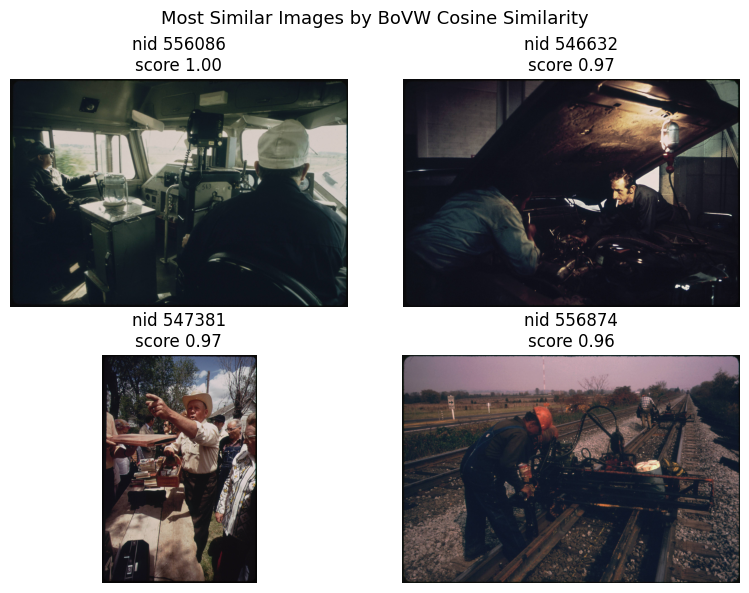

In [19]:
# Visual check by displaying the top 4 matches
show_idx = top_idx[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for ax_i, idx in zip(axes, show_idx):
    img = Image.open(demo_df.loc[idx, "full_path"])
    ax_i.imshow(img)
    ax_i.set_title(f"nid {int(demo_df.loc[idx, 'nid'])}\nscore {sim_scores[idx]:.2f}")
    ax_i.axis("off")

plt.suptitle("Most Similar Images by BoVW Cosine Similarity", fontsize=13)
plt.tight_layout()
plt.show()

A higher cosine similarity indicates stronger overlap in texture and local structure under the BoVW representation.

Clustering complements this by grouping images without labels, revealing recurring visual patterns from an unsupervised perspective.

Similarity is pairwise, while clustering summarizes corpus-level structure.

In [20]:
# Cluster BoVW features into 3 groups and visualize in 2D
n_clusters = 3
cluster_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = cluster_model.fit_predict(bovw_features)
demo_df["cluster"] = cluster_labels

# Compute the PCA
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(bovw_features)


# Create a DataFrame for visualization
clustering_visualization_df = pd.DataFrame({
    "PCA 1": xy[:, 0],
    "PCA 2": xy[:, 1],
    "Cluster": cluster_labels.astype(str),  # Convert to string for discrete colors
    "Title": demo_df["title"].apply(lambda t: textwrap.fill(str(t).lower(), 
                                                            width=50).replace('\n', '<br>')),
    "Image ID": demo_df["img_path"],
    "Category": demo_df["category"].str.lower()
})

# Create an interactive scatter plot
fig = px.scatter(
    clustering_visualization_df,
    x="PCA 1",
    y="PCA 2",
    color="Cluster",
    hover_data={
        "Title": True,
        "Image ID": True,
        "Category": True,
        "PCA 1": False,
        "PCA 2": False,
        "Cluster": True
    },
    title="BoVW Image Clusters (PCA view)",
    color_discrete_sequence=px.colors.qualitative.G10,  # A high-contrast palette
    width=800, height=600
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

print("Cluster sizes:")
print(demo_df["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    34
1    11
2     5
Name: count, dtype: int64


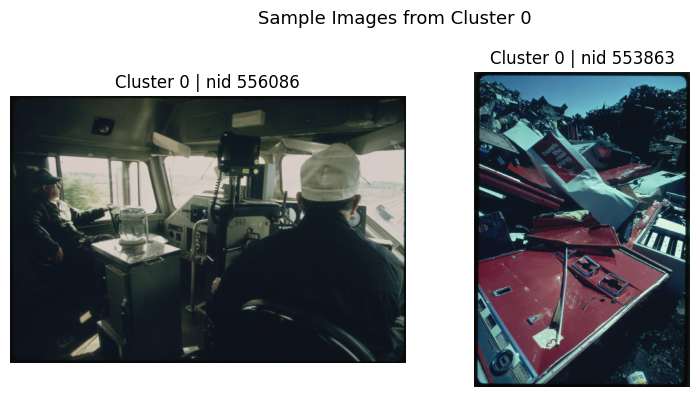

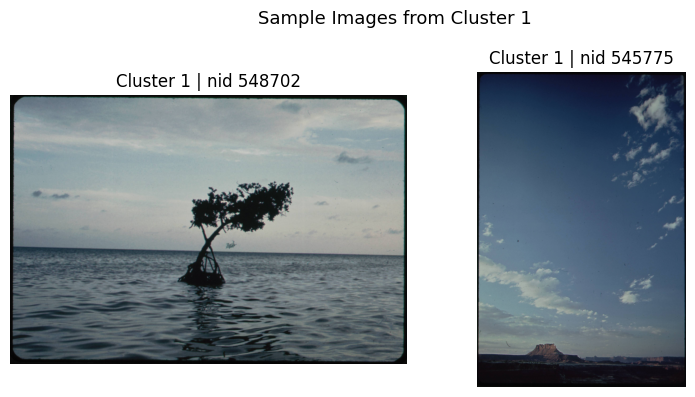

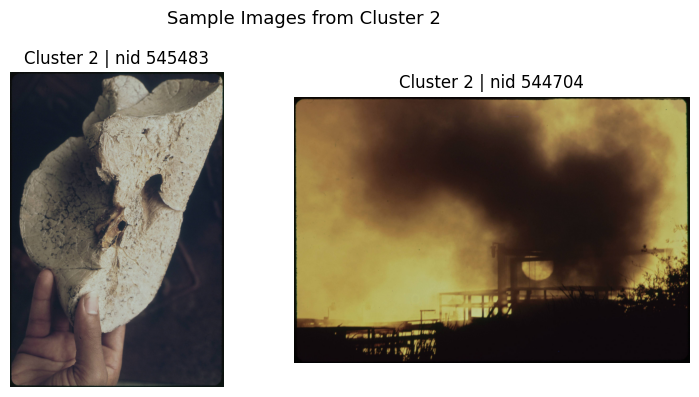

In [21]:
# Display 2 images from each cluster to see if they share visual themes
for cluster_id in sorted(np.unique(cluster_labels)):
    
    cluster_images = demo_df[demo_df["cluster"] == cluster_id].head(2)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax_i, (_, row) in zip(axes, cluster_images.iterrows()):
        img = Image.open(row["full_path"])
        ax_i.imshow(img)
        ax_i.set_title(f"Cluster {cluster_id} | nid {int(row['nid'])}")
        ax_i.axis("off")
    plt.suptitle(f"Sample Images from Cluster {cluster_id}", fontsize=13)
    plt.tight_layout()
    plt.show()

> Reflection: which visual cues (edges, textures, layouts, or contrast patterns) likely drove these images into the same cluster?

## 3. Deep Learng: Convolutional Neural Networks and Vision Transformers

Next we transition from handcrafted BoVW descriptors to learned semantic representations. 

Although BoVW is itself a type of "embedding", it is only looking at local features in an image, **Convolutional Neural Networks** (CNNs) and **Vision Transformers** (ViTs) on the other hand, can produce a "larger picture" understanding of images and therefore achieve better performance.

#### 3.1 CNN and Embeddings

Convolutional Neural Networks (CNNs) are a type of deep learning model specifically designed for processing structured grid data, such as images. 

They are inspired by the way the human brain processes visual information. A CNN consists of multiple layers, each with a specific role:

- **Convolutional Layers**: These layers detect patterns such as edges, textures, or shapes in small regions of the image.
- **Pooling Layers**: These layers reduce the spatial dimensions of the data, making the model more efficient and robust to variations.
- **Fully Connected Layers**: These layers combine the extracted features to make predictions.

The benefit of multiple layers is that they allow the network to learn hierarchical features. Early layers focus on simple patterns like edges, while deeper layers capture more complex structures, such as objects or scenes. This hierarchical learning enables CNNs to excel at tasks like image classification, object detection, and more.

Here, we will use a pre-trained ResNet 18 model:

![](media/Original-ResNet-18-Architecture.png)

In [22]:
# Harmonize the metadf to ensure we have the correct paths for all images, which will be useful for future steps.
meta_df["img_path"] = meta_df["nid"].astype(int).astype(str) + ".jpg"
meta_df["full_path"] = meta_df["img_path"].apply(lambda p: os.path.join(IMAGE_DIR, p))

In [23]:
# Load a pretrained CNN and define small helper utilities
# Use CPU by default so this runs anywhere, but switch to GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# A compact image size keeps full-dataset embedding fast.
IMG_SIZE = 160
BATCH_SIZE = 32

weights = ResNet18_Weights.DEFAULT
cnn_model = resnet18(weights=weights).to(device).eval()

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

# We tap into multiple ResNet stages for visualization, and avgpool for final embedding.
feature_extractor = create_feature_extractor(
    cnn_model,
    return_nodes={
        "layer1": "layer1",
        "layer2": "layer2",
        "layer3": "layer3",
        "layer4": "layer4",
        "avgpool": "embedding",
    },
).to(device).eval()

print(f"Loaded model: {type(cnn_model).__name__}")

Using device: cpu
Loaded model: ResNet


We begin by transforming one image as an example:

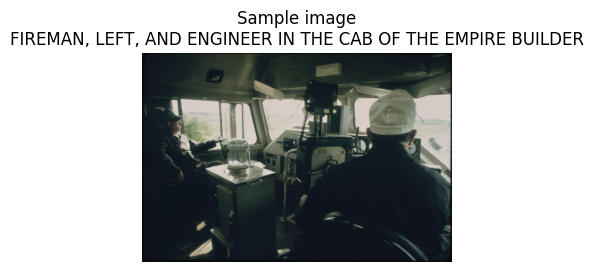

In [24]:
# Show one image and feature maps from different convolution stages
sample_idx = 0
sample_path = demo_df.loc[sample_idx, "full_path"]
sample_title = str(demo_df.loc[sample_idx, "title"])

img_pil = Image.open(sample_path).convert("RGB")
img_tensor = preprocess(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    fmap_outputs = feature_extractor(img_tensor)

# Display original image
plt.figure(figsize=(4, 4))
plt.imshow(img_pil)
plt.title(f"Sample image\n{sample_title[:60]}")
plt.axis("off")
plt.show()

Feature maps represent the intermediate outputs of a Convolutional Neural Network (CNN) as it processes an image. 

Each feature map highlights specific patterns or structures detected by the network at a particular layer. 

- **Early Layers**: The plots from early layers show the model focusing on low-level features such as edges, corners, and simple textures. These layers capture fine-grained details and local patterns in the image.  
- **Middle Layers**: The plots from intermediate layers reveal the model identifying more complex structures, such as repeated patterns, shapes, or parts of objects. These layers combine low-level features into more meaningful representations.  
- **Deeper Layers**: The plots from deeper layers highlight the models focus on high-level, abstract features. These layers capture semantic information, such as the overall context, objects, or scene-level understanding.  

By analyzing these plots, we can infer how the model progressively builds its understanding of the image, layer by layer.

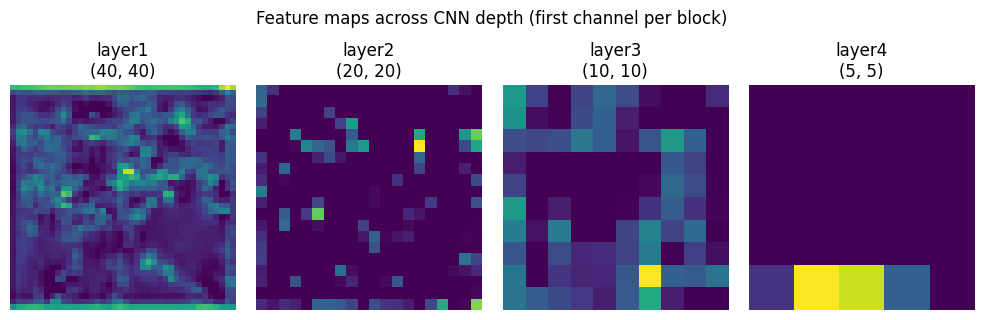

In [25]:
# Show first channel from each stage to keep the view simple and readable
layers_to_show = ["layer1", "layer2", "layer3", "layer4"]
fig, axes = plt.subplots(1, len(layers_to_show), figsize=(10, 3))

for ax, layer_name in zip(axes, layers_to_show):
    fmap = fmap_outputs[layer_name][0, 0].detach().cpu().numpy()  # [H, W] for one channel
    ax.imshow(fmap, cmap="viridis")
    ax.set_title(f"{layer_name}\n{fmap.shape}")
    ax.axis("off")

plt.suptitle("Feature maps across CNN depth (first channel per block)", y=1.05)
plt.tight_layout()
plt.show()

We can see clearly that early layers keeps more local textures and edges, while deeper layers become more abstract and semantic. This is why CNN embeddings often group images by meaning, not just raw pixels.

Next, we batch-process all images in `meta_df` to build one CNN embedding per image. We downscale inputs for speed so this runs comfortably on a local machine.

In [26]:
# Create a custom Dataset class to load and preprocess images in batches for embedding extraction
class DemoImageDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        path = row["full_path"]
        
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        ok = True
        
        return x, idx, ok

In [27]:
dataset = DemoImageDataset(meta_df, preprocess)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

all_embeddings = np.zeros((len(meta_df), 512), dtype=np.float32)
valid_mask = np.zeros(len(meta_df), dtype=bool)

with torch.no_grad():
    for xb, idxb, okb in loader:
        xb = xb.to(device)
        out = feature_extractor(xb)["embedding"]  # [B, 512, 1, 1]
        emb = out.flatten(start_dim=1).detach().cpu().numpy()  # [B, 512]

        idx_np = idxb.numpy()
        all_embeddings[idx_np] = emb
        valid_mask[idx_np] = okb.numpy().astype(bool)
        
# This should be (N, 512) where N is the number of successfully processed images in our demo batch: 50
print(f"Embeddings shape: {all_embeddings.shape}")
print(f"Valid images: {valid_mask.sum()} / {len(valid_mask)}")

# Keep everything aligned with meta_df
meta_df["cnn_valid"] = valid_mask
meta_df["cnn_emb_idx"] = np.arange(len(meta_df))

Embeddings shape: (197, 512)
Valid images: 197 / 197


A single embedding is just a numeric fingerprint of an image. 

The embedding of each image exists as a list of numbers, with each number representing a feature of the image. For the model we used, there are 512 dimensions for each image.

In [28]:
# Peek at what embeddings look like
print("Embedding matrix:", all_embeddings.shape)
print("One embedding (first 50 dimensions):")
print(np.round(all_embeddings[0, :50], 4))

Embedding matrix: (197, 512)
One embedding (first 50 dimensions):
[0.0322 3.8814 1.5009 0.5262 1.5885 0.6313 2.0569 1.5281 1.4761 1.1877
 2.667  0.81   0.0576 0.4404 2.0375 0.6879 0.2922 0.6384 0.8566 1.6851
 0.     0.3846 0.4314 2.1512 2.5046 0.102  0.538  3.1172 0.0655 2.3766
 3.1108 0.9091 0.3246 0.2546 0.41   1.1546 1.7438 1.3666 0.4784 2.4637
 1.0099 0.9566 0.     0.0213 0.9301 2.24   0.6773 1.064  1.8874 0.9562]


In [29]:
# Quick projection to 2D for visual intuition
pca_preview = PCA(n_components=2, random_state=123)
xy_preview = pca_preview.fit_transform(all_embeddings)

# Create a DataFrame for visualization
pca_preview_df = pd.DataFrame({
    "PC1": xy_preview[:, 0],
    "PC2": xy_preview[:, 1],
    "Category": meta_df["category"].str.lower(),
    "Title": meta_df["title"].apply(lambda t: textwrap.fill(str(t).lower(), 
                                                            width=50).replace('\n', '<br>')),
    "Image ID": meta_df["img_path"]
})

# Create an interactive scatter plot
fig = px.scatter(
    pca_preview_df,
    x="PC1",
    y="PC2",
    color="Category",
    hover_data={
        "Title": True,
        "Image ID": True,
        "PC1": False,
        "PC2": False,
        "Category": True
    },
    title="CNN Embeddings Projected to 2D (PCA)",
    color_discrete_sequence=px.colors.qualitative.G10,  # A high-contrast palette
    width=800, height=600
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

In [30]:
# Save embeddings and light metadata for future use
save_dir = Path("data/embeddings")

emb_path = save_dir / "cnn_resnet18_embeddings.npy"
meta_path = save_dir / "cnn_resnet18_embedding_metadata.csv"

np.save(emb_path, all_embeddings)

save_cols = ["nid", "title", "category", "full_path", "cnn_valid", "cnn_emb_idx"]
meta_df[save_cols].to_csv(meta_path, index=False)

We saved both vectors and metadata keeps the workflow modular. Now we can reuse these CNN embeddings for classification, retrieval, and comparison against ViT embeddings without recomputing.

#### 3.2 ViT Embedding

Now we repeat the same exploration flow with a Vision Transformer (ViT).

Unlike CNNs that slide convolution kernels, ViT splits an image into patches and learns global relationships through self-attention.

- Self-attention lets each patch look at all the other patches and weight which ones are most relevant.
- Think of it as every patch asking: "Which parts of the image help me understand this patch?"
- The model then combines information from the most important patches to form a richer, global view.
- This helps ViT capture long-range relationships (like objects and context spread across the image).

<img src = "media/ViT_architecture.png" width =600>

In [31]:
# Load a pretrained ViT and set up helpers
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit_weights = ViT_B_16_Weights.DEFAULT
vit_model = vit_b_16(weights=vit_weights).to(device).eval()
vit_preprocess = vit_weights.transforms()

# If this cell is rerun, remove old hooks
if "vit_hook_handles" in globals():
    for handle in vit_hook_handles:
        handle.remove()

# Capture hidden states from a few transformer blocks for visualization.
vit_block_outputs = {}
vit_hook_handles = []
block_indices_to_capture = [0, 5, 11]

for idx in block_indices_to_capture:
    handle = vit_model.encoder.layers[idx].register_forward_hook(
        lambda module, inputs, output, idx=idx: vit_block_outputs.__setitem__(f"block_{idx+1}", output.detach())
    )
    vit_hook_handles.append(handle)

print("Loaded model: ViT-B/16")

Loaded model: ViT-B/16


ViT gives us a complementary style of representation: patch-to-patch relationships are modeled globally, which can capture broader scene context.

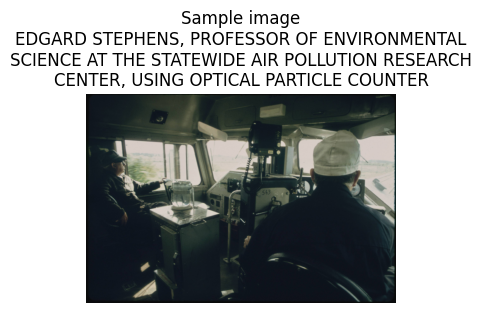

In [32]:
# Display one image and patch-response maps from different ViT blocks
vit_sample_idx = 0
vit_sample_path = demo_df.loc[vit_sample_idx, "full_path"]
vit_sample_title = str(meta_df.loc[vit_sample_idx, "title"])

vit_img_pil = Image.open(vit_sample_path).convert("RGB")
vit_x = vit_preprocess(vit_img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    _ = vit_model(vit_x)

# Original image
plt.figure(figsize=(4, 4))
plt.imshow(vit_img_pil)
plt.title(f"Sample image\n{textwrap.fill(vit_sample_title, width=50)}")
plt.axis("off")
plt.show()

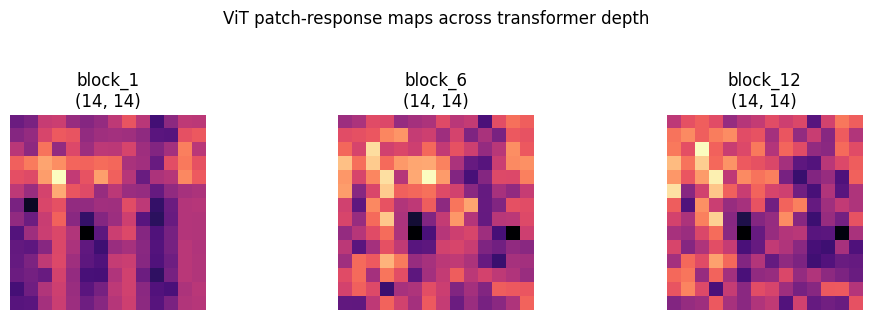

In [33]:
# Build simple patch-level response maps from selected transformer blocks
# Output shape per block: [B, num_tokens, hidden_dim] where token 0 is [CLS]
fig, axes = plt.subplots(1, len(block_indices_to_capture), figsize=(10, 3))

for ax, idx in zip(axes, block_indices_to_capture):
    block_name = f"block_{idx+1}"
    tokens = vit_block_outputs[block_name][0]            # [num_tokens, hidden_dim]
    patch_tokens = tokens[1:, :]                         # remove CLS token
    patch_strength = patch_tokens.mean(dim=1).cpu().numpy()

    grid_size = int(np.sqrt(len(patch_strength)))
    patch_map = patch_strength.reshape(grid_size, grid_size)

    ax.imshow(patch_map, cmap="magma")
    ax.set_title(f"{block_name}\n{patch_map.shape}")
    ax.axis("off")

plt.suptitle("ViT patch-response maps across transformer depth", y=1.05)
plt.tight_layout()
plt.show()

Earlier blocks focus on local patch patterns, while deeper blocks become more semantic. Even this simple patch map gives a useful intuition for how ViT features evolve.

In [34]:
# Generate ViT embeddings for the full meta_df in batches
class ViTDemoImageDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        path = row["full_path"]
        try:
            img = Image.open(path).convert("RGB")
            x = self.transform(img)
            ok = True
        except Exception:
            x = torch.zeros(3, 224, 224)
            ok = False
        return x, idx, ok

In [35]:
vit_dataset = ViTDemoImageDataset(meta_df, vit_preprocess)
vit_loader = torch.utils.data.DataLoader(vit_dataset, batch_size=BATCH_SIZE, shuffle=False)

vit_all_embeddings = np.zeros((len(meta_df), 768), dtype=np.float32)
vit_valid_mask = np.zeros(len(meta_df), dtype=bool)

with torch.no_grad():
    for xb, idxb, okb in vit_loader:
        xb = xb.to(device)

        # Forward manually to obtain pre-head features (CLS representation)
        feats = vit_model._process_input(xb)
        n = feats.shape[0]
        cls_token = vit_model.class_token.expand(n, -1, -1)
        feats = torch.cat([cls_token, feats], dim=1)
        feats = vit_model.encoder(feats)
        cls_emb = feats[:, 0]  # [B, 768]

        idx_np = idxb.numpy()
        vit_all_embeddings[idx_np] = cls_emb.detach().cpu().numpy()
        vit_valid_mask[idx_np] = okb.numpy().astype(bool)

print(f"ViT embeddings shape: {vit_all_embeddings.shape}")
print(f"Valid images: {vit_valid_mask.sum()} / {len(vit_valid_mask)}")

meta_df["vit_valid"] = vit_valid_mask
meta_df["vit_emb_idx"] = np.arange(len(meta_df))

ViT embeddings shape: (197, 768)
Valid images: 197 / 197


Now each image has a 768-dimensional ViT embedding. Nearby vectors should reflect similar global visual context.

In [36]:
# Step 4 — Inspect ViT embeddings and quick 2D projection
print("ViT embedding matrix:", vit_all_embeddings.shape)
print("One embedding (first 50 dims):")
print(np.round(vit_all_embeddings[0, :50], 4))

ViT embedding matrix: (197, 768)
One embedding (first 50 dims):
[ 0.9998  0.7323 -0.2628  0.1922 -0.4931  0.1466  0.3872  0.4602  1.1134
 -0.4166 -0.5085 -0.0026 -0.9519  0.6645 -0.5356 -0.7836  0.6449  0.1533
  0.5651 -0.0997 -0.3318  0.3294 -0.3245  0.4026 -0.6311 -0.5472  0.1692
  0.8504 -0.0809  0.2273  0.4106  0.2785 -0.2128 -1.367  -1.0587  0.4089
 -0.0591  0.635   0.3544 -1.2851 -0.442   0.1638  0.0282  0.2741  0.3705
 -0.4775  0.3156  0.5612 -1.2059  1.1339]


In [37]:
vit_pca_preview = PCA(n_components=2, random_state=123)
vit_xy_preview = vit_pca_preview.fit_transform(vit_all_embeddings)

# Create a DataFrame for visualization
vit_pca_preview_df = pd.DataFrame({
    "PC1": vit_xy_preview[:, 0],
    "PC2": vit_xy_preview[:, 1],
    "Category": meta_df["category"].str.lower(),
    "Title": meta_df["title"].apply(lambda t: textwrap.fill(str(t).lower(), 
                                                            width=50).replace('\n', '<br>')),
    "Image ID": meta_df["img_path"]
})

# Create an interactive scatter plot
fig = px.scatter(
    vit_pca_preview_df,
    x="PC1",
    y="PC2",
    color="Category",
    hover_data={
        "Title": True,
        "Image ID": True,
        "PC1": False,
        "PC2": False,
        "Category": True
    },
    title="ViT Embeddings Projected to 2D (PCA)",
    color_discrete_sequence=px.colors.qualitative.G10,  # A high-contrast palette
    width=800, height=600
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

These clusters are unsupervised visual groups. They won’t perfectly match labels, but they are very helpful for exploration and retrieval.

In [38]:
# Save ViT embeddings and metadata for future use
save_dir = Path("data/embeddings")

vit_emb_path = save_dir / "vit_b16_embeddings.npy"
vit_meta_path = save_dir / "vit_b16_embedding_metadata.csv"

np.save(vit_emb_path, vit_all_embeddings)

vit_save_cols = ["nid", "title", "category", "full_path", "vit_valid", "vit_emb_idx"]
meta_df[vit_save_cols].to_csv(vit_meta_path, index=False)

Similarly, we saved the generated embeddings for future reuse.

#### 3.3 CNN vs ViT: model-family comparison

In the previous section, we created **CNN-style** and **ViT-style** embeddings on the same data.

Now let's make a comparison to build intuition about common behaviors of these two model families.

In [39]:
# Setup for CNN vs ViT comparison

# Keep rows where both embeddings are valid
comparison_mask = meta_df["cnn_valid"].fillna(False) & meta_df["vit_valid"].fillna(False)
comparison_idx = np.where(comparison_mask.values)[0]

cnn_cmp = all_embeddings[comparison_idx]
vit_cmp = vit_all_embeddings[comparison_idx]
labels_cmp = meta_df.loc[comparison_idx, "category"].astype(str).values

# L2 normalize for cosine similarity comparison and clustering
def l2_normalize(x: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

cnn_cmp_n = l2_normalize(cnn_cmp)
vit_cmp_n = l2_normalize(vit_cmp)

We first align a shared subset where both embeddings exist, so the comparison is fair and one-to-one.

  Model Family  Top-5 same-category ratio
0   CNN family                      0.319
1   ViT family                      0.384


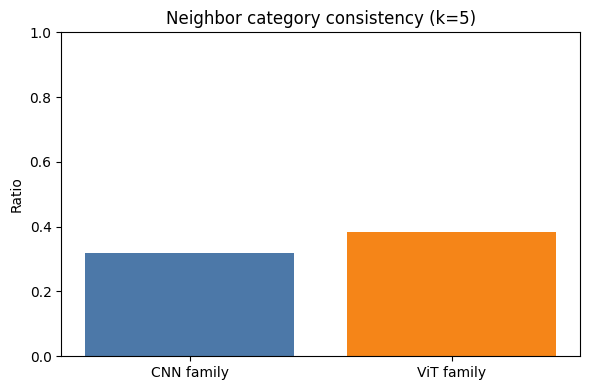

In [40]:
# Neighbor category consistency (shared retrieval-style metric)
def neighbor_agreement(emb: np.ndarray, labels: np.ndarray, k: int = 5) -> float:
    # Ensure labels is a standard numpy array to support 2D indexing
    labels = np.array(labels)
    
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
    nn.fit(emb)
    _, indices = nn.kneighbors(emb)

    # skip self neighbor at column 0
    neighbor_labels = labels[indices[:, 1:]]
    same = (neighbor_labels == labels[:, None]).mean()
    return float(same)

k = 5
cnn_neighbor_score = neighbor_agreement(cnn_cmp_n, labels_cmp, k=k)
vit_neighbor_score = neighbor_agreement(vit_cmp_n, labels_cmp, k=k)

neighbor_df = pd.DataFrame({
    "Model Family": ["CNN family", "ViT family"],
    f"Top-{k} same-category ratio": [cnn_neighbor_score, vit_neighbor_score],
})

print(neighbor_df.round(3))

plt.figure(figsize=(6, 4))
plt.bar(neighbor_df["Model Family"], neighbor_df[f"Top-{k} same-category ratio"], color=["#4C78A8", "#F58518"])
plt.ylim(0, 1)
plt.title(f"Neighbor category consistency (k={k})")
plt.ylabel("Ratio")
plt.tight_layout()
plt.show()

How to read this result? Note that the ViT model has a higher category consistency score, so the embeddings it created outperformed the ResNet model in preserving same categories in neighborhoods.

This however does **not** mean ViT always wins. It means that on this dataset split, ViT embeddings grouped categories a bit more cleanly.

In [41]:
# Perturbation sensitivity profile (local vs global changes)

# Define a few simple perturbations to apply to the images and see how much they change the embeddings.
def cnn_embed_one(img_pil: Image.Image) -> np.ndarray:
    x = preprocess(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        e = feature_extractor(x)["embedding"].flatten(start_dim=1).cpu().numpy()[0]
    return e

# ViT's forward is a bit more complex since we want to capture the CLS token before the head, so we replicate that logic here for single images.
def vit_embed_one(img_pil: Image.Image) -> np.ndarray:
    x = vit_preprocess(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        feats = vit_model._process_input(x)
        cls_token = vit_model.class_token.expand(feats.shape[0], -1, -1)
        feats = torch.cat([cls_token, feats], dim=1)
        feats = vit_model.encoder(feats)
        e = feats[:, 0].cpu().numpy()[0]
    return e


# Calculate the cosine similarity between two vectors, with a small epsilon to prevent division by zero
def cosine(a: np.ndarray, b: np.ndarray, eps: float = 1e-9) -> float:
    return float(np.dot(a, b) / ((np.linalg.norm(a) + eps) * (np.linalg.norm(b) + eps)))


# A simple perturbation that occludes the center of the image, which often contains key objects or features
def center_occlude(img_pil: Image.Image, frac: float = 0.35) -> Image.Image:
    arr = np.array(img_pil).copy()
    h, w, _ = arr.shape
    oh, ow = int(h * frac), int(w * frac)
    y0 = (h - oh) // 2
    x0 = (w - ow) // 2
    arr[y0:y0+oh, x0:x0+ow] = 0
    return Image.fromarray(arr)


In [42]:
# Define a few perturbations to apply to the images and see how much they change the embeddings.
perturbations = {
    "blur (local texture loss)": lambda img: img.filter(ImageFilter.GaussianBlur(radius=2)),
    "color shift": lambda img: TF.adjust_saturation(TF.adjust_brightness(img, 1.25), 0.6),
    "center occlusion (global content loss)": lambda img: center_occlude(img, frac=0.35),
}

rng = np.random.default_rng(123)
n_probe = min(12, len(comparison_idx))
probe_global_idx = rng.choice(comparison_idx, size=n_probe, replace=False)

rows = []
for gidx in probe_global_idx:
    img = Image.open(meta_df.loc[gidx, "full_path"]).convert("RGB")

    cnn_ref = cnn_embed_one(img)
    vit_ref = vit_embed_one(img)

    for perturb_name, perturb_fn in perturbations.items():
        img_p = perturb_fn(img)
        cnn_sim = cosine(cnn_ref, cnn_embed_one(img_p))
        vit_sim = cosine(vit_ref, vit_embed_one(img_p))

        rows.append({
            "perturbation": perturb_name,
            "cnn_cosine": cnn_sim,
            "vit_cosine": vit_sim,
        })

In [43]:
# Calculate the average cosine similarity for each perturbation type and model family, then reshape for visualization
perturb_df = pd.DataFrame(rows).groupby("perturbation", as_index=False).mean(numeric_only=True)
perturb_long = perturb_df.melt(
    id_vars="perturbation",
    value_vars=["cnn_cosine", "vit_cosine"],
    var_name="model_family",
    value_name="mean_cosine_similarity",
)
perturb_long["model_family"] = perturb_long["model_family"].map({
    "cnn_cosine": "CNN family",
    "vit_cosine": "ViT family",
})
# Display the dataframe with rounded values for better readability
perturb_df["cnn_cosine"] = perturb_df["cnn_cosine"].round(3)
perturb_df["vit_cosine"] = perturb_df["vit_cosine"].round(3)
display(perturb_df)

,perturbation,cnn_cosine,vit_cosine
0,blur (local texture loss),1.000,0.997
1,center occlusion (global content loss),0.787,0.715
2,color shift,0.978,0.969


In [44]:
fig = px.bar(
    perturb_long,
    x="perturbation",
    y="mean_cosine_similarity",
    color="model_family",
    barmode="group",
    title="Embedding stability under image perturbations",
    height=400, width=700,
)
fig.update_layout(yaxis_title="Higher = embedding changed less")
fig.show()

How to read this perturbation test? Higher cosine means the embedding changed less.

In fact, both models were very stable to blur/color changes here, but both changed more when central content was removed. The key takeaway is to focus on the **pattern** of sensitivity, not just one score.

In [45]:
# Side-by-side retrieval behavior (qualitative)
def top_neighbors(emb_norm: np.ndarray, query_local_idx: int, top_n: int = 4):
    sims = emb_norm @ emb_norm[query_local_idx]
    order = np.argsort(-sims)
    order = [idx for idx in order if idx != query_local_idx][:top_n]
    return order, sims

rng = np.random.default_rng(2026)
query_local_idx = int(rng.integers(0, len(comparison_idx)))
query_global_idx = int(comparison_idx[query_local_idx])

cnn_nbrs, cnn_sims = top_neighbors(cnn_cmp_n, query_local_idx, top_n=4)
vit_nbrs, vit_sims = top_neighbors(vit_cmp_n, query_local_idx, top_n=4)

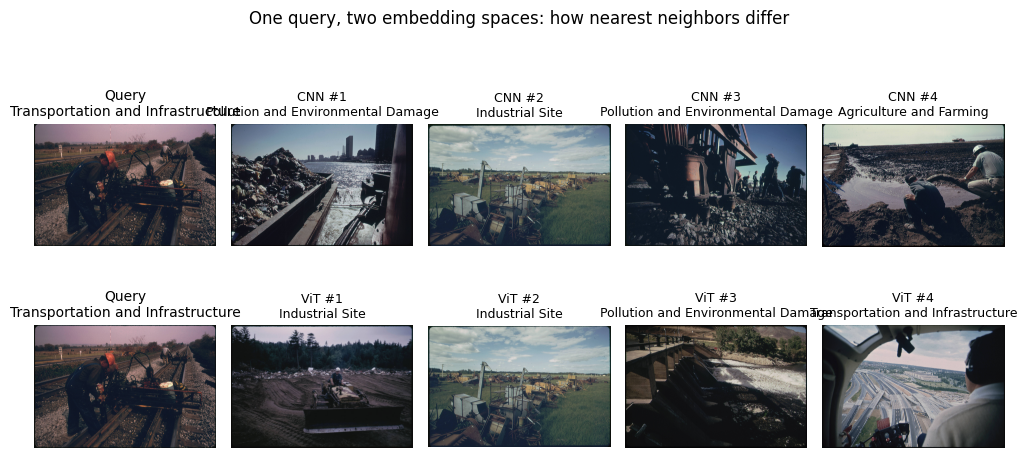

In [46]:
# Set up a side-by-side visualization of the query image and its nearest neighbors in both embedding spaces
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Column 0: query image (same in both rows)
query_img = Image.open(meta_df.loc[query_global_idx, "full_path"]).convert("RGB")
query_title = str(meta_df.loc[query_global_idx, "title"])
query_cat = str(meta_df.loc[query_global_idx, "category"])

for r in [0, 1]:
    axes[r, 0].imshow(query_img)
    axes[r, 0].set_title(f"Query\n{query_cat}", fontsize=10)
    axes[r, 0].axis("off")

# Row 0: CNN neighbors
for j, local_idx in enumerate(cnn_nbrs, start=1):
    gidx = int(comparison_idx[local_idx])
    img = Image.open(meta_df.loc[gidx, "full_path"]).convert("RGB")
    cat = str(meta_df.loc[gidx, "category"])
    axes[0, j].imshow(img)
    axes[0, j].set_title(f"CNN #{j}\n{cat}", fontsize=9)
    axes[0, j].axis("off")

# Row 1: ViT neighbors
for j, local_idx in enumerate(vit_nbrs, start=1):
    gidx = int(comparison_idx[local_idx])
    img = Image.open(meta_df.loc[gidx, "full_path"]).convert("RGB")
    cat = str(meta_df.loc[gidx, "category"])
    axes[1, j].imshow(img)
    axes[1, j].set_title(f"ViT #{j}\n{cat}", fontsize=9)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("CNN family", fontsize=11)
axes[1, 0].set_ylabel("ViT family", fontsize=11)
plt.suptitle("One query, two embedding spaces: how nearest neighbors differ", y=1.02)
plt.tight_layout()
plt.show()

> **Reflectio**: In the side-by-side retrieval panel, what did each model seem to prioritize: local visual texture, or broader scene context?

The quantitative scores gave ViT a small edge on neighbor consistency for our data, while both families remained fairly robust to mild perturbations.

Use this as a practical rule:
- CNN-style models are often efficient and strong when local patterns matter.
- ViT-style models often help when global relationships across the image matter.

For real projects, always compare both on your own data before deciding.

## 4. Image Classification

Image classification is a fundamental task in image analysis. It involves assigning a label or category to an image based on its visual content. 

However, this task is not just about labeling images; it forms the backbone of many advanced applications such as **Optical Character Recognition (OCR)**, **Object Detection**, **Image Captioning (img2txt)**, and even **Image Generation**. 

By teaching machines to classify images, we enable them to understand and interpret visual data, which is crucial for solving real-world problems like medical diagnosis, autonomous driving, and content moderation.

### 4.1 Classification using embeddings as features

Imagine you are studying how public space changed over time (community life, industrial development, and ecology) using image data (photos or remote sensing scannings). Instead of labeling every image manually, we can label a small subset and use image embeddings as compact features and train a simple classifier to assist coding.

What we are going to do next, is to train a simple **logistic regression**-based classifier on our two sets of embeddings.

You can think of logistic regression as a smart sorting rule that looks at each image's numeric summary (embedding) and asks: "How likely is this image to belong to each category?"

- It combines many small clues from the embedding into one score.
- It turns that score into a **probability** (from 0 to 1).
- It then picks the category with the highest probability.

During training, the model learns from examples we already labeled and gradually adjusts how much each clue should matter.  

In [47]:
# A short and friendly baseline: Logistic Regression on frozen embeddings

# Process the data and perform train/test split, keeping splits for both models the same
X_cnn = all_embeddings[meta_df["cnn_emb_idx"].astype(int).values]
X_vit = vit_all_embeddings[meta_df["vit_emb_idx"].astype(int).values]

y_text = meta_df["category"].astype(str).values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
idx = np.arange(len(meta_df))
train_idx, test_idx = train_test_split(idx, test_size=0.25, random_state=42, stratify=y)

X_cnn_train, X_cnn_test = X_cnn[train_idx], X_cnn[test_idx]
X_vit_train, X_vit_test = X_vit[train_idx], X_vit[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [48]:
# Fit a simple logistic regression classifier on each embedding space
cnn_clf = LogisticRegression(max_iter=3000, random_state=42)
vit_clf = LogisticRegression(max_iter=3000, random_state=42)

cnn_clf.fit(X_cnn_train, y_train)
vit_clf.fit(X_vit_train, y_train)

cnn_pred = cnn_clf.predict(X_cnn_test)
vit_pred = vit_clf.predict(X_vit_test)

To evaluate how well the classifiers worked, we use two simple metrics:

- **Accuracy** = the share of images the model labeled correctly overall.  
    - Example: 0.80 accuracy means 80 out of 100 images were correctly classified.

- **Macro F1-score** = how balanced the model is across all categories, not just the largest group.  
    - It rewards models that are both **precise** (few false alarms) and **complete** (few missed cases) for each class.

In short: **accuracy** tells us overall correctness, while **Macro F1** tells us whether performance is fair and reliable across all categories.

In [49]:
# Calculate accuracy and macro F1 score for both models to compare their performance on the classification task.
cnn_acc = accuracy_score(y_test, cnn_pred)
vit_acc = accuracy_score(y_test, vit_pred)
cnn_f1 = f1_score(y_test, cnn_pred, average="macro")
vit_f1 = f1_score(y_test, vit_pred, average="macro")

results_df = pd.DataFrame({
    "Model family": ["CNN embedding + Logistic Regression", "ViT embedding + Logistic Regression"],
    "Accuracy": [cnn_acc, vit_acc],
    "Macro F1": [cnn_f1, vit_f1],
}).round(3)

display(results_df)

,Model family,Accuracy,Macro F1
0,CNN embedding + Logistic Regression,0.48,0.301
1,ViT embedding + Logistic Regression,0.54,0.321


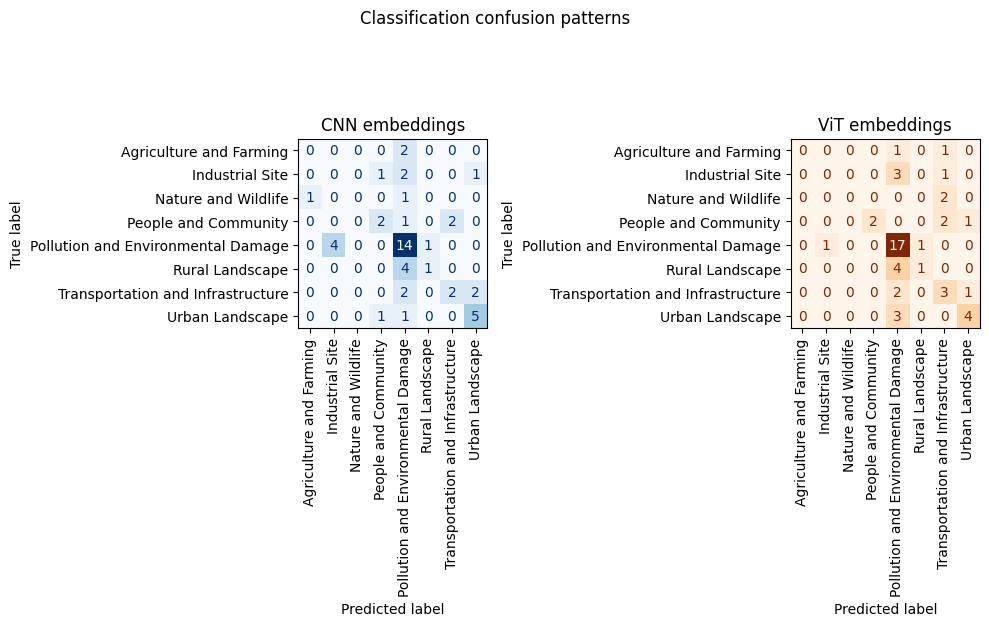

In [50]:
# Quick visual check: where each model gets confused
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
ConfusionMatrixDisplay.from_predictions(y_test, cnn_pred, 
                                        display_labels=label_encoder.classes_, 
                                        ax=axes[0], xticks_rotation=90, cmap="Blues", colorbar=False)
axes[0].set_title("CNN embeddings")

ConfusionMatrixDisplay.from_predictions(y_test, vit_pred, 
                                        display_labels=label_encoder.classes_, 
                                        ax=axes[1], xticks_rotation=90, cmap="Oranges", colorbar=False)
axes[1].set_title("ViT embeddings")

plt.suptitle("Classification confusion patterns", y=1.04)
plt.tight_layout()
plt.show()

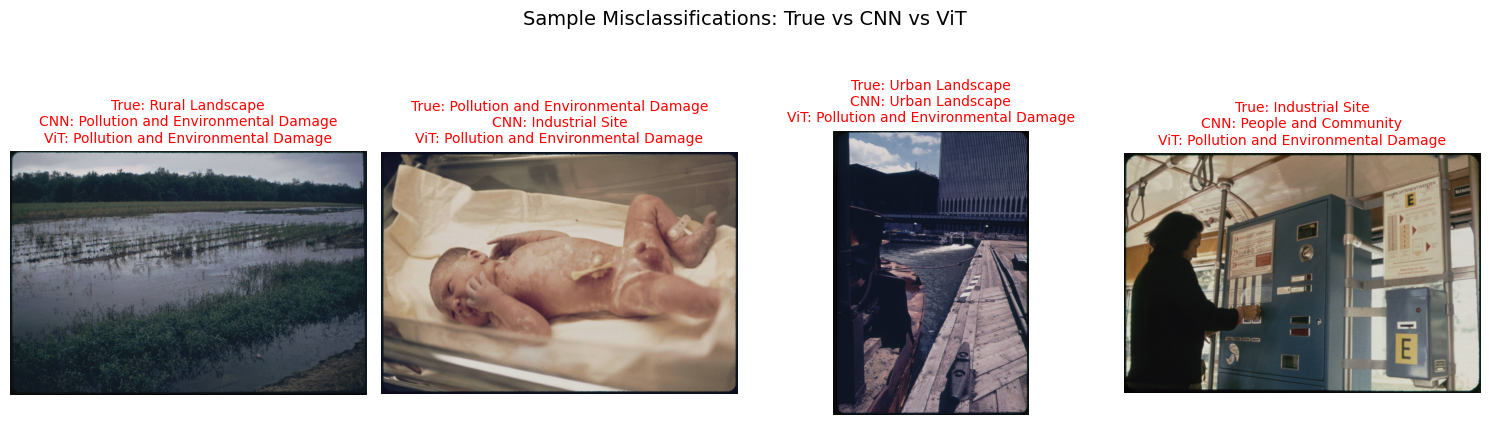

In [51]:
# Find test samples where at least one model made a mistake
wrong_preds = [i for i in range(len(y_test)) if cnn_pred[i] != y_test[i] or vit_pred[i] != y_test[i]]

num_samples = min(4, len(wrong_preds))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
    
for ax, i in zip(axes, wrong_preds[:num_samples]):
    global_idx = test_idx[i]
    img = Image.open(meta_df.loc[global_idx, "full_path"]).convert("RGB")
        
    true_label = label_encoder.inverse_transform([y_test[i]])[0]
    cnn_label = label_encoder.inverse_transform([cnn_pred[i]])[0]
    vit_label = label_encoder.inverse_transform([vit_pred[i]])[0]
        
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nCNN: {cnn_label}\nViT: {vit_label}", fontsize=10, color="red")
    ax.axis("off")

plt.suptitle("Sample Misclassifications: True vs CNN vs ViT", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


The workflow can be summarized as follows:
- We represented each photo as a compact numeric summary (an embedding).  
- We then trained a simple classifier to map those summaries to social-science categories.  
- This helps researchers pre-sort large archives before manual coding.  
- The model does not replace human judgment; it reduces repetitive screening work.

> **Reflection**: Based on the above results, what model seems to have performed better on our sample? How much would you trust the labels given by the trained classifiers?

### 4.2 Classification using classification head

### 4.3 Multi-label classification and object detections

### 4.4 Optical Character Recognition

### 4.5 Image Captioning 